In [1]:
import os
import numpy as np
import scipy.io as sio
from scipy.ndimage import label, find_objects, gaussian_filter1d
from scipy.signal import find_peaks
import matplotlib.pyplot as plt


In [35]:
#functions for artifact removal
# did not use them

def find_gamma_peaks(signal, WindowSize=60*200, OverlapPercentage=20, LocalQuantile=0.975, GlobalQuantile=0.9):
    signal = np.asarray(signal)
    overlap_samples = int(np.round(WindowSize * OverlapPercentage / 100))
    step_size = WindowSize - overlap_samples
    peaks = []
    for i in range(0, len(signal) - WindowSize + 1, step_size):
        window = signal[i:i+WindowSize]
        threshold = np.quantile(window, LocalQuantile)
        above_threshold = (window > threshold)
        labeled_array, num_features = label(above_threshold, structure=np.ones((3,)))
        if num_features > 0:
            blob_slices = find_objects(labeled_array)
            for s in blob_slices:
                segment = window[s[0]]
                max_idx = np.argmax(segment)
                signal_idx = i + s[0].start + max_idx
                peaks.append(signal_idx)
    if not peaks:
        return np.array([], dtype=int)
    peaks = np.unique(peaks)
    global_threshold = np.quantile(signal, GlobalQuantile)
    peak_values = signal[peaks]
    final_peaks = peaks[peak_values >= global_threshold]
    return final_peaks


def create_artifact_mask(peak_indices, signal_length, eeg_t, nsec_remove):
    dt = np.median(np.diff(eeg_t))
    fs = np.floor(1 / dt)
    Nsamp_remove = int(fs * nsec_remove)
    good_quality = np.ones(signal_length, dtype=bool)
    for peak_idx in peak_indices:
        start = max(0, peak_idx - Nsamp_remove)
        end = min(signal_length, peak_idx + Nsamp_remove + 1)
        good_quality[start:end] = False
    return good_quality




In [75]:
# subject paths
subject = "sub-racsleep04b"
subject_dir = f"/orcd/data/ldlewis/001/om/hf303/for_ore/{subject}/eeg/"
behavior_mat = f"/orcd/data/ldlewis/001/om/hf303/for_ore/{subject}/behav/{subject.replace('sub-', '')}_run01_buttonpresses_clean.mat"



In [76]:
# load cleaned EEG metrics with irregular time vector
metrics_path = os.path.join(subject_dir, "metrics.mat")
metrics = sio.loadmat(metrics_path, squeeze_me=True, struct_as_record=False)
eeg_struct = metrics["eeg"]
print(metrics)

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Mon Dec  9 16:44:47 2024', '__version__': '1.0', '__globals__': [], 'fmri': <scipy.io.matlab._mio5_params.mat_struct object at 0x2aaaf057f400>, 'eeg': <scipy.io.matlab._mio5_params.mat_struct object at 0x2aaaf057fa90>, 'behav': array([1.11000e+00, 3.33000e+00, 5.55000e+00, ..., 5.37795e+03,
       5.38239e+03, 5.38461e+03])}


In [77]:
# access EEG struct and extract cleaned α/δ metric
eeg_struct = metrics["eeg"]
eeg_t = np.squeeze(eeg_struct.t_clean)
ratio = np.squeeze(eeg_struct.alpha_delta_clean)  # already α/δ cleaned metric

print(f"EEG loaded: {len(eeg_t)} clean samples")



EEG loaded: 24645 clean samples


In [78]:
#behavioral button presses 
mat = sio.loadmat(behavior_mat)
press_times = mat['buttonpresses_clean'].flatten()
threshold = 20  # seconds of silence between arousals
intervals = np.diff(press_times)
arousal_indices = np.where(intervals >= threshold)[0] + 1
arousal_times = press_times[arousal_indices]

sustained, transient = [], []
for t in arousal_times:
    following = press_times[(press_times > t) & (press_times <= t + 20)]
    if len(following) >= 5:
        sustained.append(t)
    elif len(following) <= 2:
        transient.append(t)
sustained = np.array(sustained)
transient = np.array(transient)

print(f"Sustained arousals: {len(sustained)}")
print(f"Transient arousals: {len(transient)}")




Sustained arousals: 10
Transient arousals: 6


Detected 259 EEG-based arousals


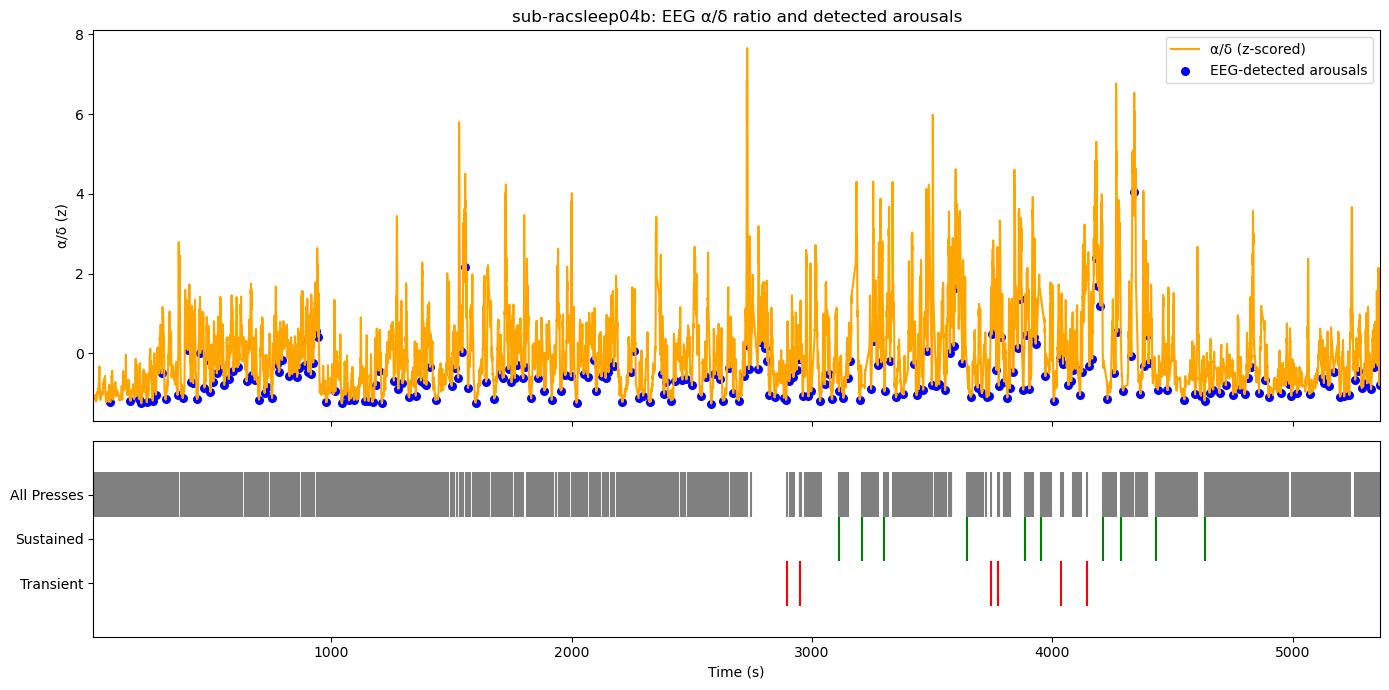

In [79]:
# Z-score the α/δ ratio 
ratio_z = (ratio - np.nanmean(ratio)) / np.nanstd(ratio)

# detect EEG-based Arousal Events 
dt = np.median(np.diff(eeg_t))
inv = -ratio_z  # invert to detect sharp downward α/δ deflections
peaks, props = find_peaks(inv, distance=int(8.0 / dt), prominence=0.8)
eeg_arousals = eeg_t[peaks]

print(f"Detected {len(eeg_arousals)} EEG-based arousals")

# plot EEG α/δ Ratio and behavioral arousals 
fig, axs = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={'height_ratios':[2,1]})

# EEG α/δ (z-scored)
axs[0].plot(eeg_t, ratio_z, color='orange', label='α/δ (z-scored)')
axs[0].scatter(eeg_arousals, np.interp(eeg_arousals, eeg_t, ratio_z),
               color='blue', s=30, label='EEG-detected arousals')
axs[0].set_ylabel("α/δ (z)")
axs[0].legend()
axs[0].set_title(f"{subject}: EEG α/δ ratio and detected arousals")

# behavioral button presses
axs[1].eventplot([press_times, sustained, transient],
                 colors=['gray', 'green', 'red'],
                 lineoffsets=[0.6, 0.3, 0.0],
                 linelengths=[0.3, 0.3, 0.3])
axs[1].set_yticks([0, 0.3, 0.6])
axs[1].set_yticklabels(["Transient", "Sustained", "All Presses"])
axs[1].set_xlabel("Time (s)")
axs[1].set_xlim(eeg_t[0], eeg_t[-1])

plt.tight_layout()
plt.show()




